# Proyecto EMNIST 

Hector Heredia - Cristopher Corona

## Introducción

* **Dataset:** **EMNIST (balanced)** — imágenes **28×28** en escala de grises con dígitos y letras.
Entrenar una **CNN** que **clasifique** correctamente el carácter, carga el dataset, hace **EDA**, **preprocesa**, **entrena**, **evalúa**, **visualiza** resultados y **guarda** el modelo.



In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
# CARGAMOS DATASET
def cargar_emnist(subset='balanced', metodo='tfds'):
    if metodo == 'tfds':
        try:
            import tensorflow_datasets as tfds
            
            # MAPEO DE NOMBRES
            dataset_name = f'emnist/{subset}'
            
            print(f"Descargando EMNIST ({subset}) con TensorFlow")
            
            ds_train = tfds.load(dataset_name, split='train', as_supervised=True, shuffle_files=False)
            ds_test = tfds.load(dataset_name, split='test', as_supervised=True, shuffle_files=False)
            
            # CONVERTIMOS A NUMPY ARRAY
            x_train, y_train = [], []
            for image, label in tfds.as_numpy(ds_train):
                x_train.append(image)
                y_train.append(label)
            
            x_test, y_test = [], []
            for image, label in tfds.as_numpy(ds_test):
                x_test.append(image)
                y_test.append(label)
            
            x_train = np.array(x_train).squeeze()
            y_train = np.array(y_train)
            x_test = np.array(x_test).squeeze()
            y_test = np.array(y_test)
            
            print(f"Cargado con exito")
            
            return (x_train, y_train), (x_test, y_test)
            
        except ImportError:
            print("TensorFlow Datasets no está instalado")
            print("Instálalo con: pip install tensorflow-datasets")
            raise
        except Exception as e:
            print(f"Error al cargar con TensorFlow Datasets: {e}")
            print("Intentando con método alternativo...")
            metodo = 'extra_keras'
    
    if metodo == 'extra_keras':
        try:
            from extra_keras_datasets import emnist
            import os
            
            # ELIMINAMOS CORRUPTOS SI HAY
            cache_dir = os.path.expanduser('~/.keras/datasets')
            zip_path = os.path.join(cache_dir, 'matlab.zip')
            
            if os.path.exists(zip_path):
                print(f"Eliminando archivo corrupto: {zip_path}")
                os.remove(zip_path)
            
            print(f"Descargando EMNIST ({subset}) con extra_keras_datasets")
            (x_train, y_train), (x_test, y_test) = emnist.load_data(type=subset)
            
            print(f"Datos cargados exitosamente")
            
            return (x_train, y_train), (x_test, y_test)
            
        except ImportError:
            print("extra_keras_datasets no está instalado.")
            print("Instálalo con: pip install extra-keras-datasets")
            raise
        except Exception as e:
            print(f"Error al cargar con extra_keras_datasets: {e}")
            raise

In [3]:
# EXPLORACIÓN DE DATOS
def explorar_dimensiones(x_train, y_train, x_test, y_test):
    """
    Muestra información básica sobre las dimensiones del dataset
    """
    print("\n" + "="*60)
    print("INFORMACIÓN BÁSICA DEL DATASET")
    print("="*60)
    
    print(f"\nConjunto de entrenamiento:")
    print(f"  - Imágenes: {x_train.shape}")
    print(f"  - Etiquetas: {y_train.shape}")
    print(f"  - Tipo de datos (X): {x_train.dtype}")
    print(f"  - Tipo de datos (y): {y_train.dtype}")
    
    print(f"\nConjunto de prueba:")
    print(f"  - Imágenes: {x_test.shape}")
    print(f"  - Etiquetas: {y_test.shape}")
    
    print(f"\nCaracterísticas de las imágenes:")
    print(f"  - Tamaño: {x_train.shape[1]}x{x_train.shape[2]} píxeles")
    print(f"  - Rango de valores: [{x_train.min()}, {x_train.max()}]")
    print(f"  - Valor medio: {x_train.mean():.2f}")
    print(f"  - Desviación estándar: {x_train.std():.2f}")

def explorar_clases(y_train, y_test):
    """
    Analiza la distribución de clases en el dataset
    """
    print("\n" + "="*60)
    print("ANÁLISIS DE CLASES")
    print("="*60)
    
    clases_unicas_train = np.unique(y_train)
    clases_unicas_test = np.unique(y_test)
    
    print(f"\nNúmero de clases en entrenamiento: {len(clases_unicas_train)}")
    print(f"Número de clases en prueba: {len(clases_unicas_test)}")
    print(f"Rango de clases: {clases_unicas_train.min()} - {clases_unicas_train.max()}")
    
    # MUESTRAS DE CLASE
    counter_train = Counter(y_train)
    counter_test = Counter(y_test)
    
    print(f"\nEstadísticas de muestras por clase (Train):")
    muestras_train = list(counter_train.values())
    print(f"  - Mínimo: {min(muestras_train)} muestras")
    print(f"  - Máximo: {max(muestras_train)} muestras")
    print(f"  - Media: {np.mean(muestras_train):.0f} muestras")
    print(f"  - Mediana: {np.median(muestras_train):.0f} muestras")
    
    return counter_train, counter_test

In [4]:
def visualizar_distribucion_clases(counter_train, counter_test):
 # VEMOS DISTRIBUCION DE CLASES EN AMBOS CONJUNTOS
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # TRAIN
    clases_train = sorted(counter_train.keys())
    conteos_train = [counter_train[c] for c in clases_train]
    
    axes[0].bar(clases_train, conteos_train, color='steelblue', alpha=0.7)
    axes[0].set_xlabel('Clase', fontsize=12)
    axes[0].set_ylabel('Número de muestras', fontsize=12)
    axes[0].set_title('Distribución de Clases - Entrenamiento', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # TEST
    clases_test = sorted(counter_test.keys())
    conteos_test = [counter_test[c] for c in clases_test]
    
    axes[1].bar(clases_test, conteos_test, color='coral', alpha=0.7)
    axes[1].set_xlabel('Clase', fontsize=12)
    axes[1].set_ylabel('Número de muestras', fontsize=12)
    axes[1].set_title('Distribución de Clases - Prueba', fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def visualizar_muestras_aleatorias(x_train, y_train, n_muestras=20):
    # ALEATORIOS DEL DATASET
    indices = np.random.choice(len(x_train), n_muestras, replace=False)
    
    filas = 4
    cols = 5
    fig, axes = plt.subplots(filas, cols, figsize=(15, 12))
    fig.suptitle('Muestras Aleatorias del Dataset', fontsize=16, fontweight='bold')
    
    for i, idx in enumerate(indices):
        fila = i // cols
        col = i % cols
        
        axes[fila, col].imshow(x_train[idx], cmap='gray')
        axes[fila, col].set_title(f'Clase: {y_train[idx]}', fontsize=10)
        axes[fila, col].axis('off')
    
    plt.tight_layout()
    plt.show()

def visualizar_muestras_por_clase(x_train, y_train, n_clases=10, n_ejemplos=10):
    # EJEMPLOS DE CLASES
    clases_unicas = np.unique(y_train)
    clases_seleccionadas = np.random.choice(clases_unicas, min(n_clases, len(clases_unicas)), replace=False)
    
    fig, axes = plt.subplots(n_clases, n_ejemplos, figsize=(20, 2*n_clases))
    fig.suptitle('Ejemplos por Clase', fontsize=16, fontweight='bold')
    
    for i, clase in enumerate(clases_seleccionadas):
        # INDICES
        indices_clase = np.where(y_train == clase)[0]
        indices_muestra = np.random.choice(indices_clase, min(n_ejemplos, len(indices_clase)), replace=False)
        
        for j, idx in enumerate(indices_muestra):
            if n_clases == 1:
                ax = axes[j]
            else:
                ax = axes[i, j]
            
            ax.imshow(x_train[idx], cmap='gray')
            if j == 0:
                ax.set_ylabel(f'Clase {clase}', fontsize=10, fontweight='bold')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [5]:
def analizar_intensidad_pixeles(x_train):
    # DISTRIBUCION DE LA INTENSIDAD DE PIXELES
    print("\n" + "="*60)
    print("ANÁLISIS DE INTENSIDAD DE PÍXELES")
    print("="*60)
    
    # CALCULO DE ESTADISTICAS
    pixel_media = x_train.mean(axis=0)
    pixel_std = x_train.std(axis=0)
    
    print(f"\nIntensidad promedio global: {x_train.mean():.2f}")
    print(f"Desviación estándar global: {x_train.std():.2f}")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # HISTOGRAMA DE INTENSIDADES
    axes[0].hist(x_train.flatten(), bins=50, color='navy', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Valor de píxel', fontsize=12)
    axes[0].set_ylabel('Frecuencia', fontsize=12)
    axes[0].set_title('Distribución de Intensidad de Píxeles', fontsize=14, fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    # MAPA DE CALOR DE MEDIA
    im1 = axes[1].imshow(pixel_media, cmap='hot')
    axes[1].set_title('Intensidad Media por Píxel', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1])
    
    # MAPA DE CALOR DE DESVIACIÓN
    im2 = axes[2].imshow(pixel_std, cmap='viridis')
    axes[2].set_title('Desviación Estándar por Píxel', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2])
    
    plt.tight_layout()
    plt.show()

def analizar_correlacion_muestras(x_train, y_train, n_muestras=5):
    # SIMILITUD ENTRE CLASES CON MUESTRAS
    print("\n" + "="*60)
    print("ANÁLISIS DE SIMILITUD ENTRE MUESTRAS")
    print("="*60)
    
    # SELECCION DE CLASE ALEATORIA
    clase = np.random.choice(np.unique(y_train))
    indices_clase = np.where(y_train == clase)[0]
    indices_muestra = np.random.choice(indices_clase, min(n_muestras, len(indices_clase)), replace=False)
    
    # OBTENER MUESTRAS
    muestras = x_train[indices_muestra].reshape(len(indices_muestra), -1)
    
    # CALCULAMOS MATRIZ DE CORRELACION
    matriz_corr = np.corrcoef(muestras)
    
    fig = plt.figure(figsize=(18, 6))
    
    gs = fig.add_gridspec(2, n_muestras + 1, width_ratios=[1]*n_muestras + [0.05], 
                          height_ratios=[1, 2], hspace=0.3, wspace=0.3)
    
    for i, idx in enumerate(indices_muestra):
        ax = fig.add_subplot(gs[0, i])
        ax.imshow(x_train[idx], cmap='gray')
        ax.set_title(f'Muestra {i+1}', fontsize=10)
        ax.axis('off')
    
    fig.text(0.5, 0.95, f'Muestras de la Clase {clase}', 
             ha='center', fontsize=14, fontweight='bold')
    
    # MATRIZ DE CORRELACION
    ax_heatmap = fig.add_subplot(gs[1, :])
    sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, ax=ax_heatmap,
                cbar_kws={'label': 'Correlación'})
    ax_heatmap.set_title('Matriz de Correlación entre Muestras', fontsize=14, fontweight='bold')
    ax_heatmap.set_xlabel('Muestra', fontsize=12)
    ax_heatmap.set_ylabel('Muestra', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nCorrelación promedio entre muestras: {np.mean(matriz_corr[np.triu_indices_from(matriz_corr, k=1)]):.3f}")

In [6]:
# PREPROCESAMIENTO DE DATOS
def preprocesar_datos(x_train, y_train, x_test, y_test):
    # Normaliza y prepara los datos para el entrenamiento
    print("\n" + "="*60)
    print("PREPROCESAMIENTO DE DATOS")
    print("="*60)
    
    # NORMALIZAMOS VALORES DE PIXELES
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0
    
    print(f"\nDatos normalizados al rango [0, 1]")
    print(f"Nuevo rango de valores: [{x_train.min()}, {x_train.max()}]")
    
    # DIMENSION DE CANAL PARA CNN
    x_train = np.expand_dims(x_train, -1)
    x_test = np.expand_dims(x_test, -1)
    
    # NUMERO DE CLASES
    num_clases = len(np.unique(y_train))
    
    print(f"\nShape final de entrenamiento: {x_train.shape}")
    print(f"Shape final de prueba: {x_test.shape}")
    print(f"Número de clases: {num_clases}")
    
    return x_train, y_train, x_test, y_test, num_clases

In [7]:
# CREACION DE MODELO CNN
def crear_modelo_cnn(num_clases, input_shape=(28, 28, 1)):
    # RED NEURONAL CONVUCIONAL PARA LA CLASIFICACION EMNIST
    modelo = keras.Sequential([
        # CAPA 1
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # CAPA 2
        layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # CAPA 3
        layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
        
        # FLATTEN Y CAPAS DENSAS
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_clases, activation='softmax')
    ])
    
    return modelo

In [8]:
# Entrenar modelo
def entrenar_modelo(modelo, x_train, y_train, x_test, y_test, epochs=10, batch_size=128):
    # Compila y entrena el modelo
    # Compilar modelo
    modelo.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
    
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=0.00001
    )
    
    # Entrenar
    history = modelo.fit(
        x_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_split=0.1,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    # Evaluar
    test_loss, test_acc = modelo.evaluate(x_test, y_test, verbose=0)
    print(f"\nPrecisión en test: {test_acc:.4f}")
    
    return history

In [9]:
# Visualizamos resultados
def visualizar_predicciones(modelo, x_test, y_test, num_ejemplos=10):
    # Muestra predicciones del modelo
    # Hacer predicciones
    predicciones = modelo.predict(x_test[:num_ejemplos])
    clases_pred = np.argmax(predicciones, axis=1)
    
    # Visualizar
    plt.figure(figsize=(15, 6))
    for i in range(num_ejemplos):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
        color = 'green' if clases_pred[i] == y_test[i] else 'red'
        plt.title(f'Real: {y_test[i]}\nPred: {clases_pred[i]}', color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def visualizar_historial(history):
    # Visualiza el historial de entrenamiento
    plt.figure(figsize=(12, 4))
    
    # Precisión
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    plt.title('Precisión del Modelo', fontsize=14, fontweight='bold')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Pérdida
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation', linewidth=2)
    plt.title('Pérdida del Modelo', fontsize=14, fontweight='bold')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [10]:
# 1. Cargar datos
print("\n1. CARGANDO DATOS EMNIST...")
(x_train, y_train), (x_test, y_test) = cargar_emnist(subset='balanced')


1. CARGANDO DATOS EMNIST...
Descargando EMNIST (balanced) con TensorFlow
Cargado con exito



2. EXPLORANDO DATOS...

INFORMACIÓN BÁSICA DEL DATASET

Conjunto de entrenamiento:
  - Imágenes: (112800, 28, 28)
  - Etiquetas: (112800,)
  - Tipo de datos (X): uint8
  - Tipo de datos (y): int64

Conjunto de prueba:
  - Imágenes: (18800, 28, 28)
  - Etiquetas: (18800,)

Características de las imágenes:
  - Tamaño: 28x28 píxeles
  - Rango de valores: [0, 255]
  - Valor medio: 44.65
  - Desviación estándar: 84.98

ANÁLISIS DE CLASES

Número de clases en entrenamiento: 47
Número de clases en prueba: 47
Rango de clases: 0 - 46

Estadísticas de muestras por clase (Train):
  - Mínimo: 2400 muestras
  - Máximo: 2400 muestras
  - Media: 2400 muestras
  - Mediana: 2400 muestras


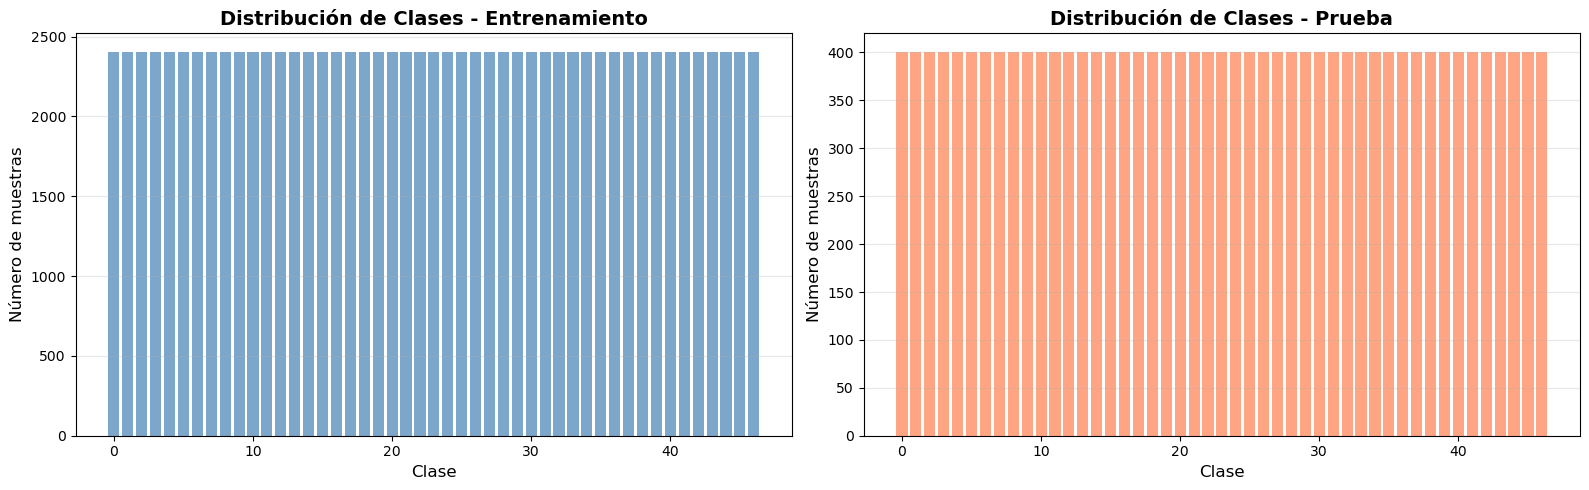

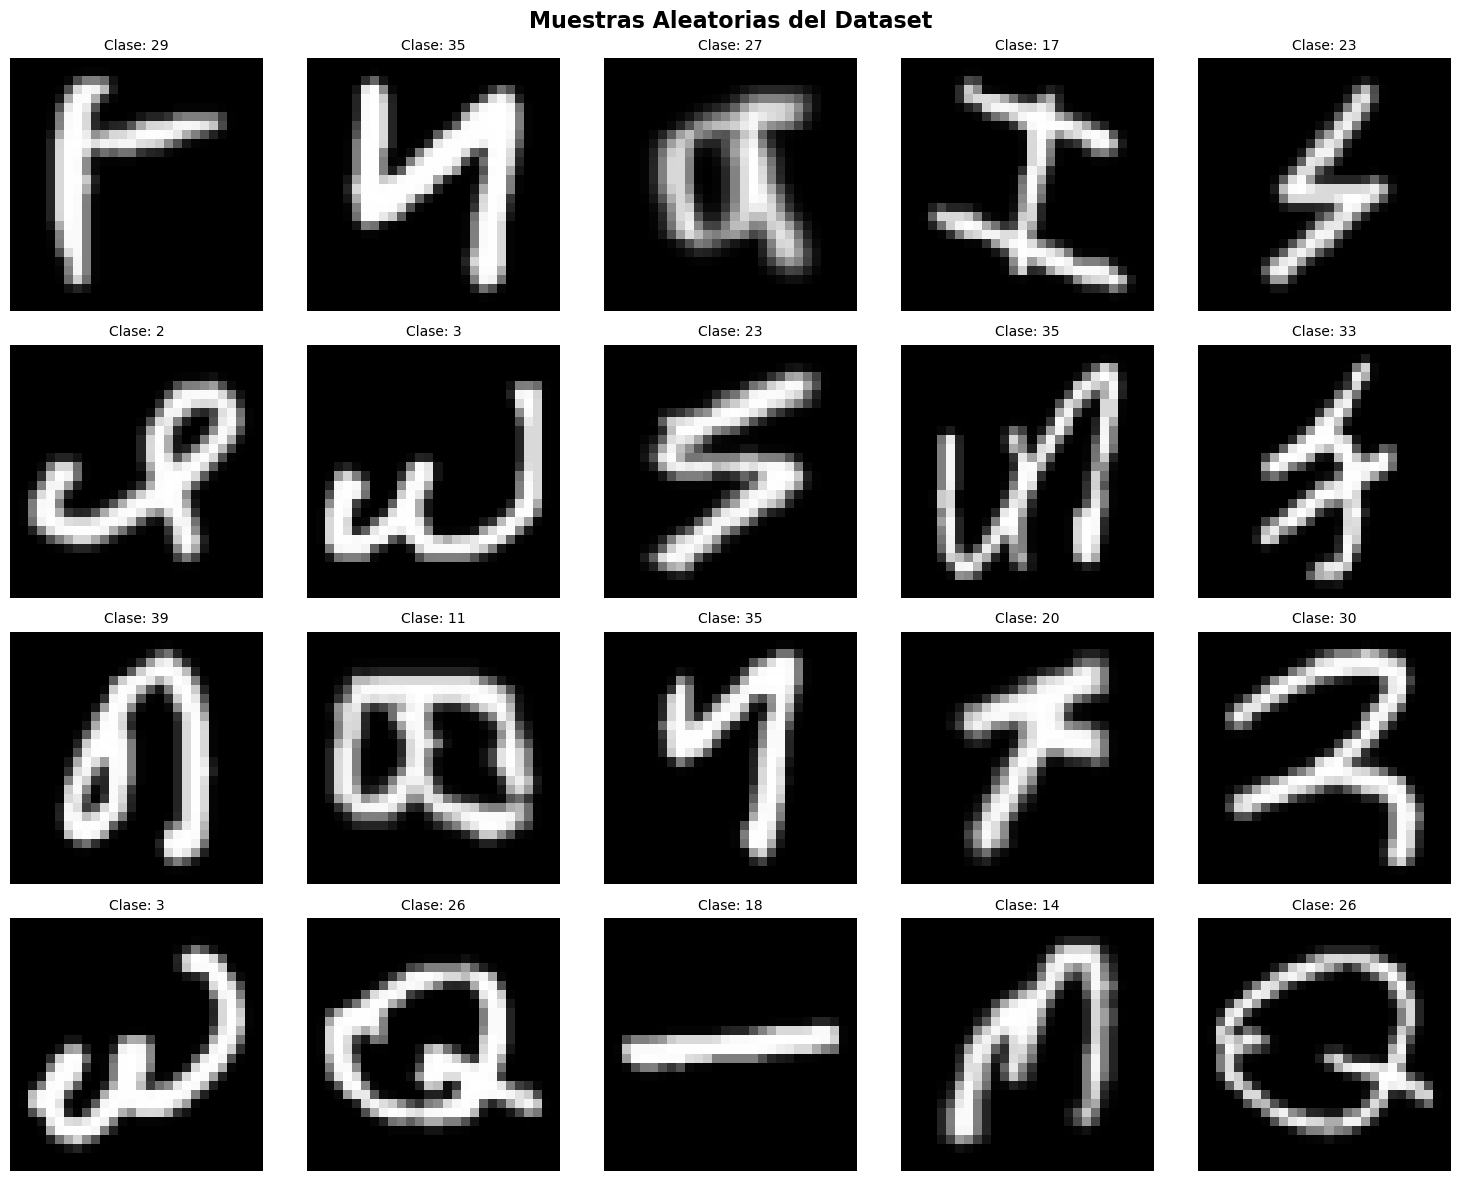

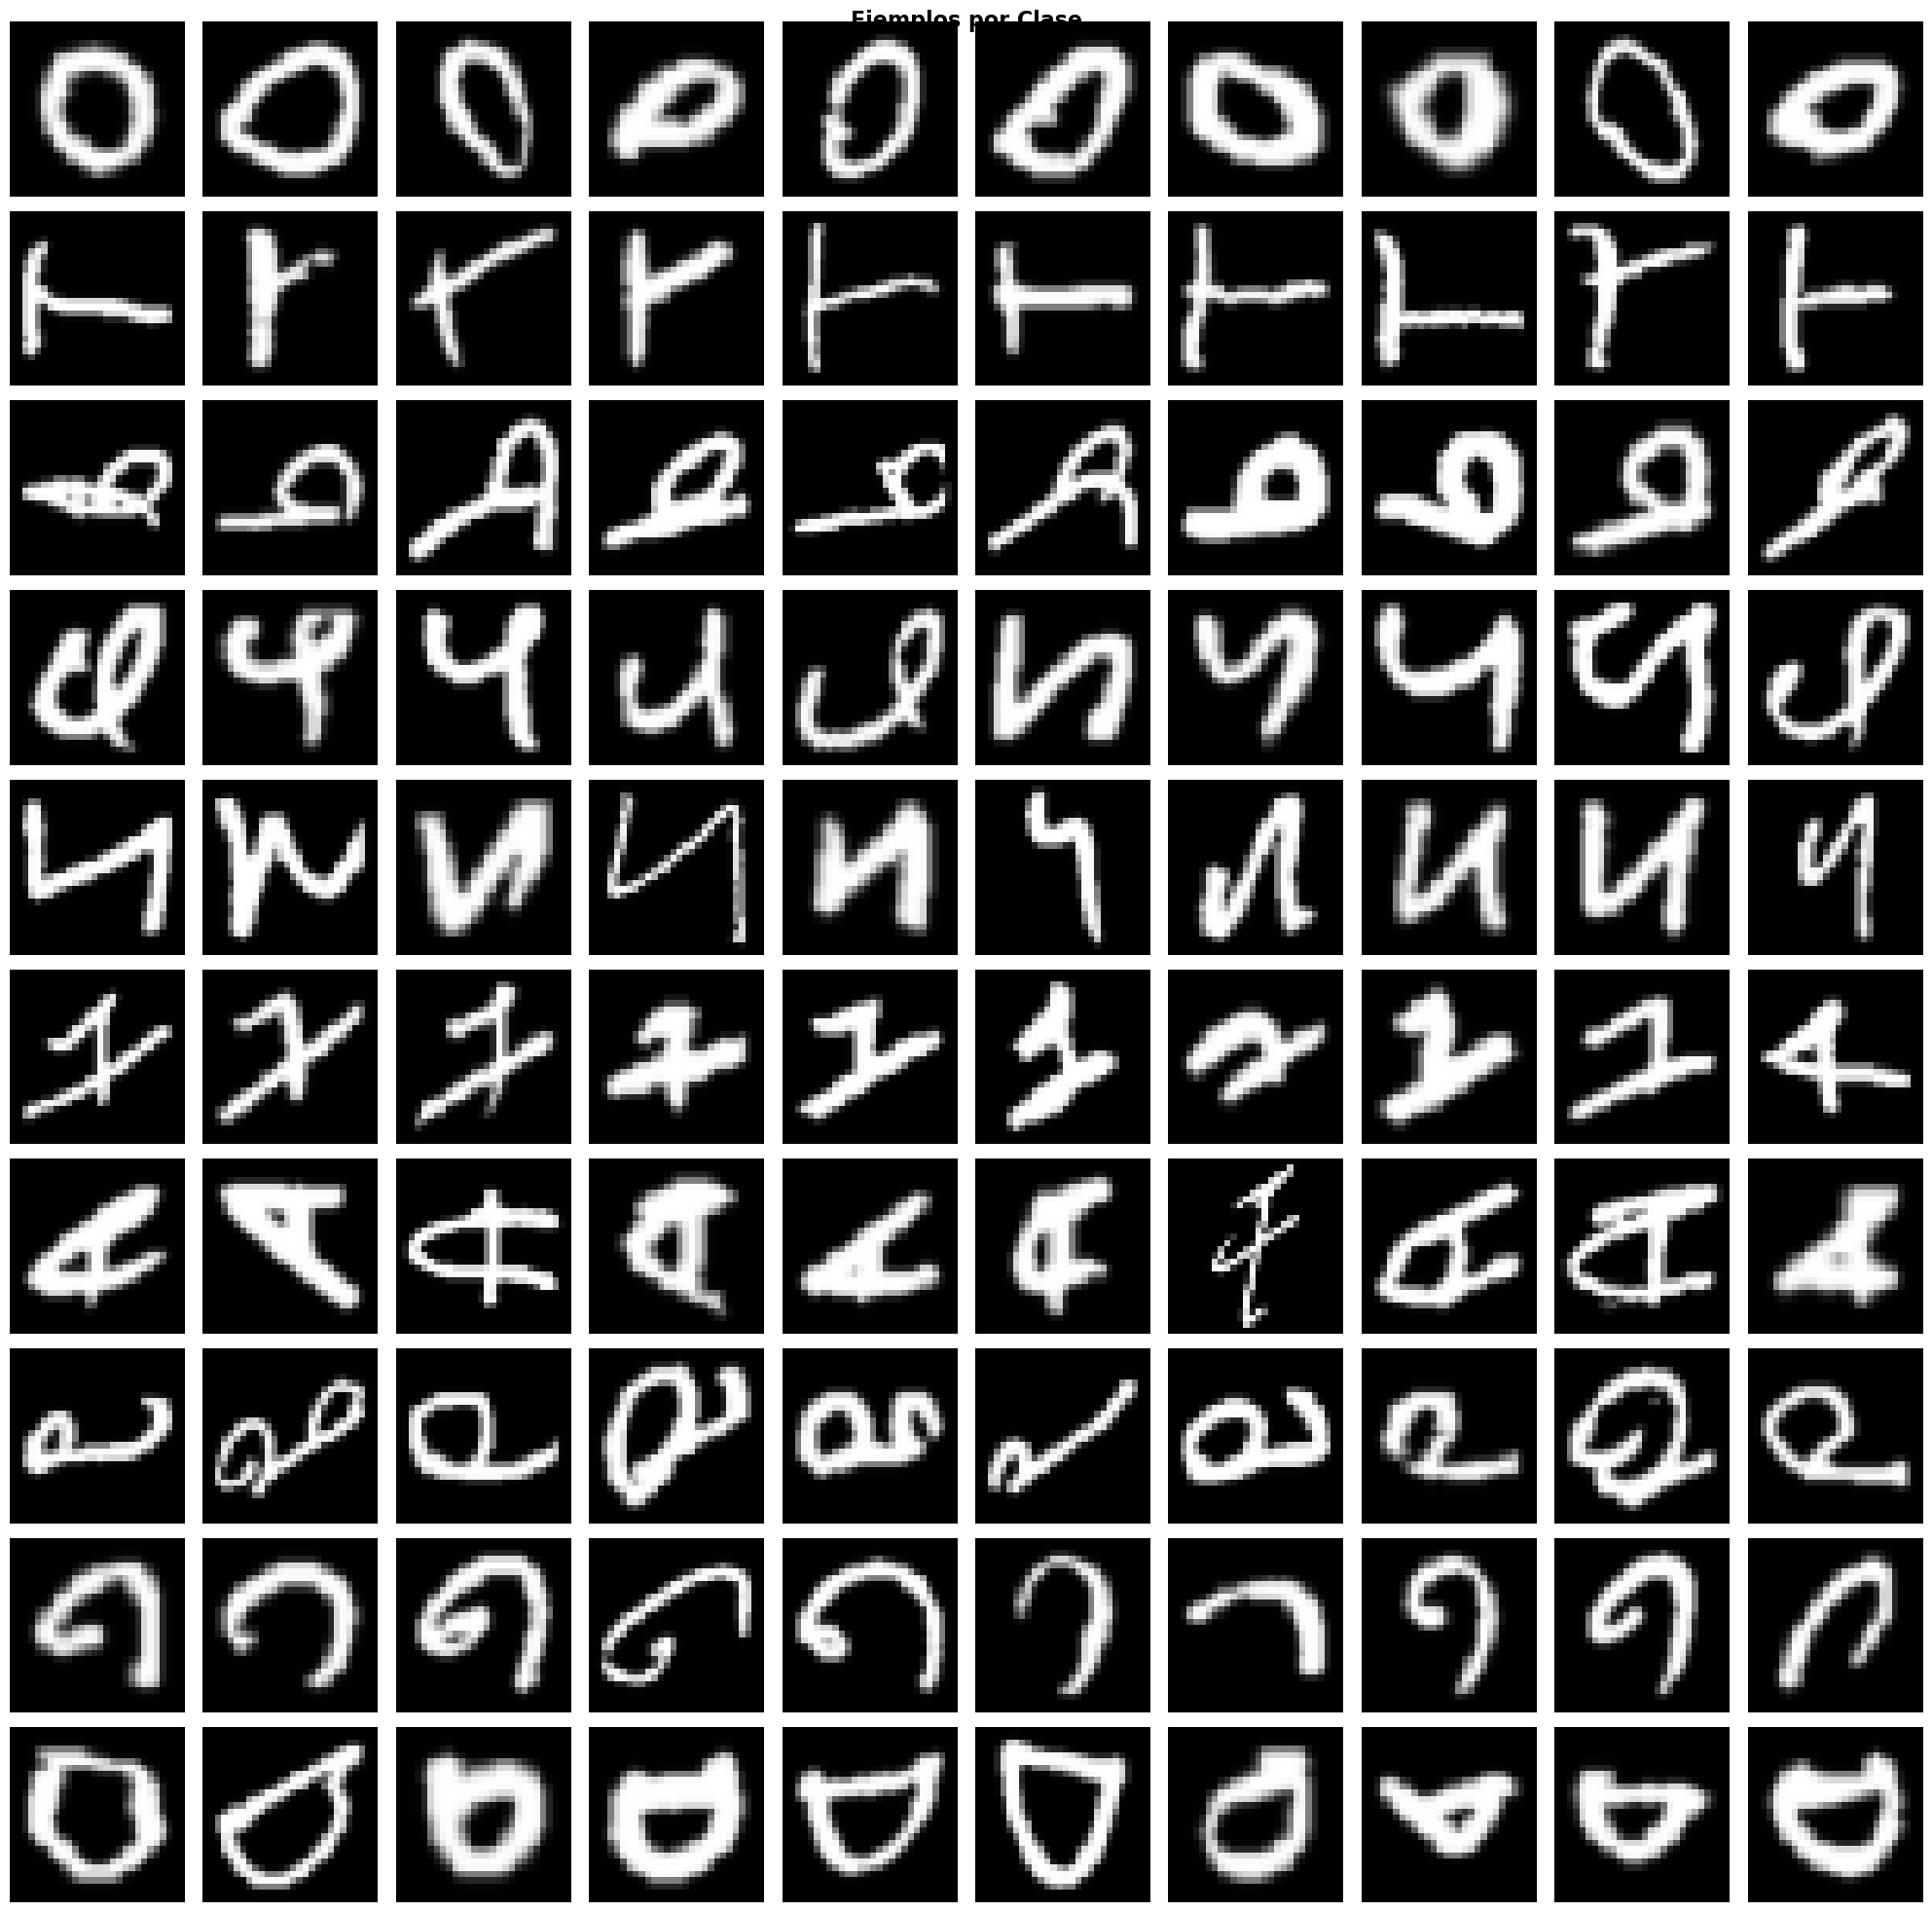


ANÁLISIS DE INTENSIDAD DE PÍXELES

Intensidad promedio global: 44.65
Desviación estándar global: 84.98


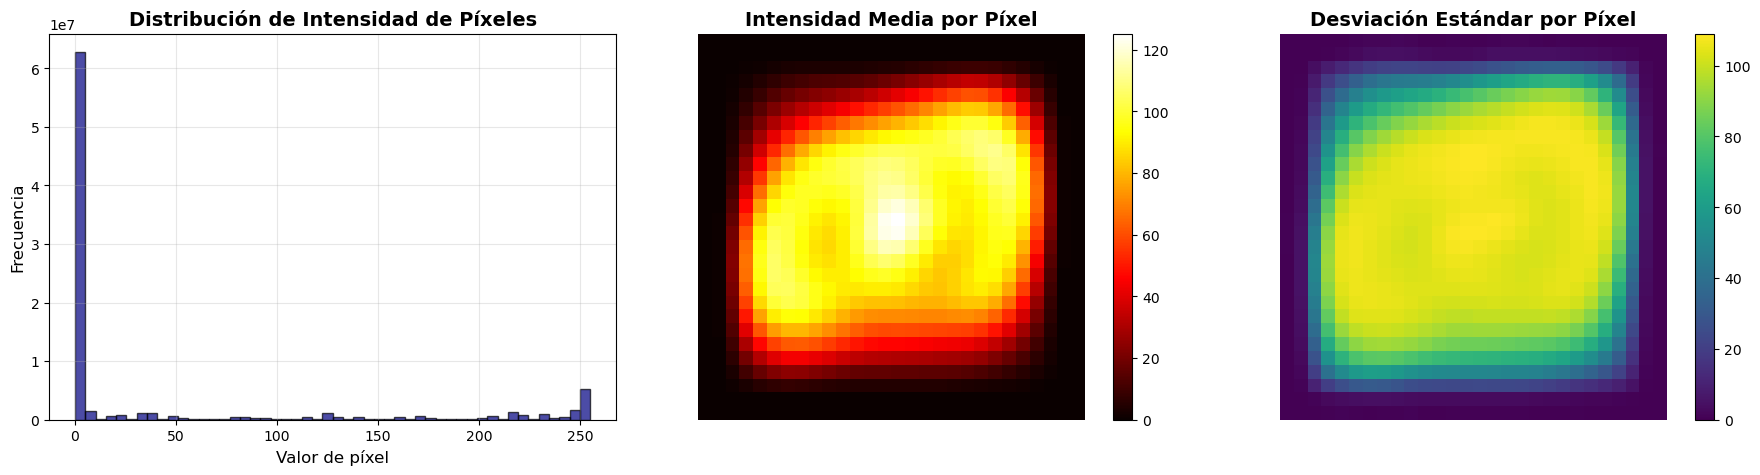


ANÁLISIS DE SIMILITUD ENTRE MUESTRAS


C:\Users\hecto\AppData\Local\Temp\ipykernel_1180\195319058.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


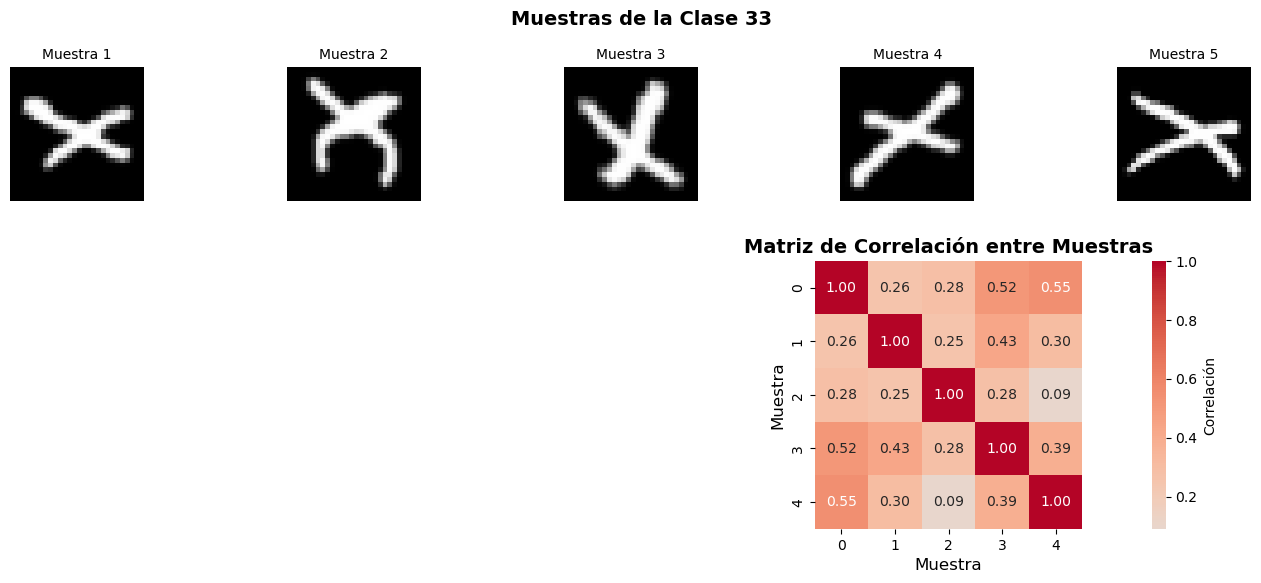


Correlación promedio entre muestras: 0.334


In [11]:
# 2. Exploración más profunda
print("\n2. EXPLORANDO DATOS...")

# Análisis dimensional
explorar_dimensiones(x_train, y_train, x_test, y_test)

# Análisis de clases
counter_train, counter_test = explorar_clases(y_train, y_test)

# Visualizaciones de distribución
visualizar_distribucion_clases(counter_train, counter_test)

# Muestras aleatorias
visualizar_muestras_aleatorias(x_train, y_train, n_muestras=20)

# Muestras por clase
visualizar_muestras_por_clase(x_train, y_train, n_clases=10, n_ejemplos=10)

# Análisis de intensidad de píxeles
analizar_intensidad_pixeles(x_train)

# Análisis de correlación
analizar_correlacion_muestras(x_train, y_train, n_muestras=5)

### Análisis de intensidad de píxeles

También analicé cómo se distribuyen las intensidades de los píxeles en todo el conjunto de training. A nivel global obtuvimos:

- Intensidad promedio global: 44.65  
- Desviación estándar global: 84.98  

En el histograma se ve claramente un pico enorme cerca de 0, lo que nos dice que la mayor parte de los píxeles son muy oscuros. Esto tiene sentido porque casi toda la imagen es fondo negro y solo una pequeña parte corresponde al trazo del carácter. Hacia la derecha del histograma aparecen intensidades más altas que llegan hasta 255, que corresponden a los trazos blancos de los dígitos y letras.

El mapa de calor de la intensidad media por píxel muestra una mancha brillante en el centro de la imagen: obvio donde normalmente se dibuja el carácter. En los bordes casi no hay intensidad, lo que indica que son regiones de fondo.

Algo parecido pasa con el mapa de la desviación estándar por píxel: la variabilidad más alta se concentra en la zona central (donde los trazos cambian de una imagen a otra) y los bordes tienen variabilidad casi nula.

En resumen, las imágenes tienen fondo oscuro bastante limpio, los caracteres están bien definidos en la zona central y no se observa ningún patrón raro de brillo que haga sospechar de problemas en los datos. Esto confirma que no hace falta aplicar correcciones fuertes de contraste antes de entrenar los modelos.

### Análisis de clases y clases potencialmente confusas

En el análisis de clases, el conteo de ejemplos por etiqueta en el conjunto de entrenamiento dio lo siguiente:

- Mínimo de muestras por clase: 2400  
- Máximo de muestras por clase: 2400  
- Media: 2400  
- Mediana: 2400  

En el conjunto de prueba cada clase tiene alrededor de 400 ejemplos. Las gráficas de barras de train y test muestran columnas prácticamente idénticas en altura para todas las clases. Esto confirma que EMNIST balanced está realmente balanceado: todas las clases tienen el mismo número de ejemplos y no hay clases “raras” con muy pocos datos.

Aunque la distribución es perfectamente uniforme, al revisar ejemplos por clase y pensando en cómo escribe la gente, es fácil imaginar algunos pares de caracteres que pueden causar confusión al modelo, por ejemplo:

- 0 y O  
- 1 y I  
- 2 y Z  
- 5 y S  
- 6 y G  
- 8 y B  

En escritura manuscrita estas diferencias se pueden volver muy sutiles. Por eso espero que, cuando vea la matriz de confusión más adelante, muchos de los errores se concentren justo en estos pares. En la segunda entrega voy a revisar ese punto con más detalle para entender en qué tipos de caracteres se equivoca más el modelo.


In [12]:
# 2.1 Revisión de calidad de datos (nulos, rangos, posibles outliers simples)
print("\n2.1 REVISIÓN DE CALIDAD DE DATOS...")

def contar_nulos(arr):
    # Convertimos a float para poder usar np.isnan sin problemas
    arr_float = arr.astype("float32")
    return np.isnan(arr_float).sum()

# Valores nulos
nulos_x_train = contar_nulos(x_train)
nulos_y_train = contar_nulos(y_train)
nulos_x_test = contar_nulos(x_test)
nulos_y_test = contar_nulos(y_test)

print(f"Valores nulos en x_train: {nulos_x_train}")
print(f"Valores nulos en y_train: {nulos_y_train}")
print(f"Valores nulos en x_test : {nulos_x_test}")
print(f"Valores nulos en y_test : {nulos_y_test}")

if all(v == 0 for v in [nulos_x_train, nulos_y_train, nulos_x_test, nulos_y_test]):
    print("=> No se encontraron valores nulos en las imágenes ni en las etiquetas.")

# Rango de valores de píxeles
print("\nRANGO DE VALORES DE PÍXELES")
print(f"x_train -> min: {x_train.min()}, max: {x_train.max()}")
print(f"x_test  -> min: {x_test.min()},  max: {x_test.max()}")

# Imágenes potencialmente vacías o casi vacías (muy poca tinta)
x_train_flat = x_train.reshape(x_train.shape[0], -1)
std_por_imagen = x_train_flat.std(axis=1)
umbral_std = 5.0  # umbral heurístico para detectar imágenes casi en blanco

imagenes_casi_vacias = np.sum(std_por_imagen < umbral_std)
print(f"\nImágenes de train con desviación estándar < {umbral_std}: {imagenes_casi_vacias}")

if imagenes_casi_vacias == 0:
    print("=> No se detectaron imágenes vacías o completamente en blanco en el conjunto de entrenamiento.")

# Revisión rápida de duplicados exactos en una muestra (para no tardar demasiado)
from collections import Counter

tam_muestra = min(5000, x_train.shape[0])
muestra_idx = np.random.choice(x_train.shape[0], size=tam_muestra, replace=False)
muestra_flat = x_train_flat[muestra_idx]

# Convertimos cada imagen de la muestra en una tupla para poder contar duplicados
hashes = [tuple(img) for img in muestra_flat]
conteo_hashes = Counter(hashes)
duplicados_muestra = sum(1 for c in conteo_hashes.values() if c > 1)

print(f"\nNúmero de imágenes duplicadas en una muestra de {tam_muestra} ejemplos: {duplicados_muestra}")
if duplicados_muestra == 0:
    print("=> En la muestra analizada no se observaron duplicados exactos.")



2.1 REVISIÓN DE CALIDAD DE DATOS...
Valores nulos en x_train: 0
Valores nulos en y_train: 0
Valores nulos en x_test : 0
Valores nulos en y_test : 0
=> No se encontraron valores nulos en las imágenes ni en las etiquetas.

RANGO DE VALORES DE PÍXELES
x_train -> min: 0, max: 255
x_test  -> min: 0,  max: 255

Imágenes de train con desviación estándar < 5.0: 0
=> No se detectaron imágenes vacías o completamente en blanco en el conjunto de entrenamiento.

Número de imágenes duplicadas en una muestra de 5000 ejemplos: 0
=> En la muestra analizada no se observaron duplicados exactos.



### Limpieza de datos

Antes de empezar con los modelos quise asegurarme de qué tan limpio viene el dataset EMNIST balanced.

Primero revisé si había valores nulos tanto en las imágenes como en las etiquetas de entrenamiento y prueba. El resultado fue:

- Valores nulos en x_train: 0  
- Valores nulos en y_train: 0  
- Valores nulos en x_test: 0  
- Valores nulos en y_test: 0  

O sea, no se encontró ningún valor nulo en todo el conjunto.

Después revisamos el rango de los píxeles y en ambos conjuntos los valores van de 0 a 255, que es justo lo esperado para imágenes en escala de grises. También calculamos la desviación estándar por imagen para detectar ejemplos prácticamente en blanco y no apareció ninguna imagen con desviación estándar menor a 5.0, así que no hay “imágenes vacías”.

Por último, tomamos una muestra aleatoria de 5000 imágenes de entrenamiento y busqué duplicados exactos. En esa muestra no se encontró ningún duplicado.

Con todo esto, la conclusión es que EMNIST balanced ya viene bastante limpio y uniforme, sin nulos, sin valores fuera de rango, sin imágenes vacías y sin duplicados evidentes. Por lo mismo, no fue necesario borrar ni corregir ejemplos, y el preprocesamiento se centra solo en normalizar los píxeles y adaptar el formato de las imágenes para los modelos que voy a probar.



In [13]:
# 3. Preprocesar
x_train, y_train, x_test, y_test, num_clases = preprocesar_datos(
    x_train, y_train, x_test, y_test
)


PREPROCESAMIENTO DE DATOS

Datos normalizados al rango [0, 1]
Nuevo rango de valores: [0.0, 1.0]

Shape final de entrenamiento: (112800, 28, 28, 1)
Shape final de prueba: (18800, 28, 28, 1)
Número de clases: 47


In [14]:
# 4. Crear modelo
print("\n3. CREANDO MODELO CNN...")
modelo = crear_modelo_cnn(num_clases)
modelo.summary()


3. CREANDO MODELO CNN...


C:\Users\hecto\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 399,919 (1.53 MB)

 Trainable params: 399,919 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# 5. Entrenar
print("\n4. ENTRENANDO MODELO...")
history = entrenar_modelo(
    modelo, x_train, y_train, x_test, y_test,
    epochs=15,
    batch_size=128
)


4. ENTRENANDO MODELO...
Epoch 1/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.6783 - loss: 1.0596 - val_accuracy: 0.8372 - val_loss: 0.4710 - learning_rate: 0.0010
Epoch 2/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.8166 - loss: 0.5392 - val_accuracy: 0.8617 - val_loss: 0.3873 - learning_rate: 0.0010
Epoch 3/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.8375 - loss: 0.4639 - val_accuracy: 0.8699 - val_loss: 0.3617 - learning_rate: 0.0010
Epoch 4/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 37s 40ms/step - accuracy: 0.8499 - loss: 0.4285 - val_accuracy: 0.8768 - val_loss: 0.3443 - learning_rate: 0.0010
Epoch 5/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.8575 - loss: 0.4036 - val_accuracy: 0.8764 - val_loss: 0.3341 - learning_rate: 0.0010
Epoch 6/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.8629 - loss: 0.3817 - val_accuracy: 0.8851 - val_loss: 0.3196 - learning_rate: 0.0010
Epoch 7/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/st


5. VISUALIZANDO RESULTADOS...


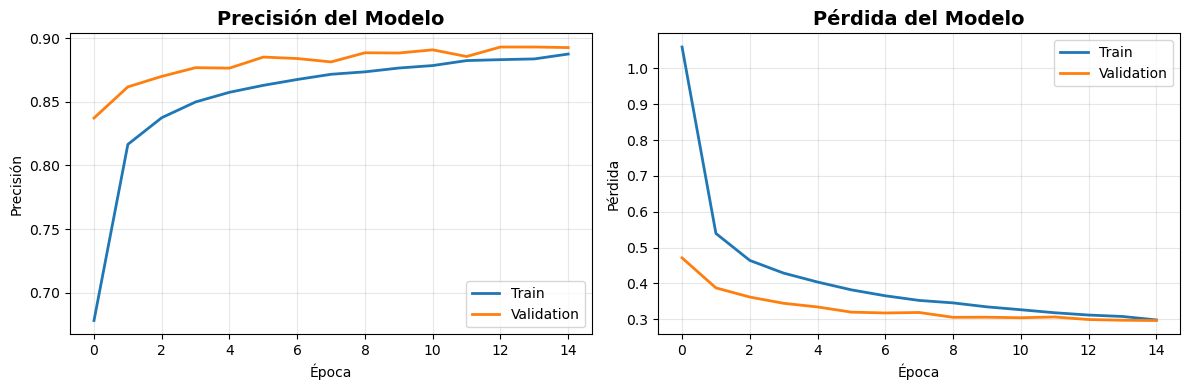

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


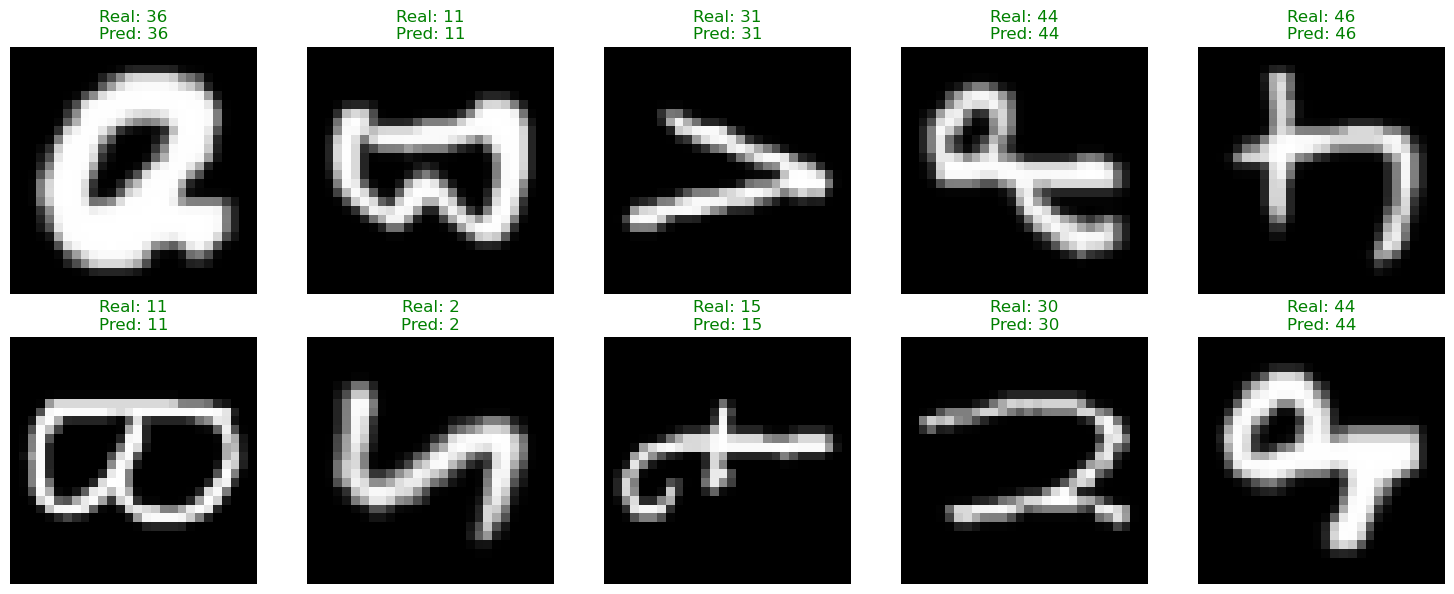

In [16]:
# 6. Visualizar resultados
print("\n5. VISUALIZANDO RESULTADOS...")
visualizar_historial(history)
visualizar_predicciones(modelo, x_test, y_test)

In [17]:
# 7. Guardar modelo
print("\n6. GUARDANDO MODELO...")
modelo.save('modelo_emnist.h5')
print("Modelo guardado como 'modelo_emnist.h5'")


6. GUARDANDO MODELO...
Modelo guardado como 'modelo_emnist.h5'


### Conclusión e hipótesis

El dataset **EMNIST balanced** es **grande, limpio y balanceado**, sin valores nulos y con clases equilibradas. Las imágenes están **bien centradas**, con fondo uniforme y trazos manuscritos, lo que lo hace ideal para entrenar modelos robustos de clasificación.

Como información clave está en **patrones espaciales locales**, nuestra **hipotesis** es que una **Red Neuronal Convolucional (CNN)** es la opción más adecuada contra modelos como regresión logística, MLP o kNN.

En las pruebas exploratorias, una **CNN sencilla de tres capas convolucionales (400k parámetros)** alcanzó alrededor de **89% de precision en validación**, con curvas de pérdida y precisión estables, lo que apoya esta hipótesis.

En la segunda entrega, a partir de este resultado y vamos a comparar 4 modelos distintos (incluyendo baselines no convolucionales) usando métricas como *accuracy*, *precision*, *recall* y *F1* para decidir, con datos, cuál es el mejor modelo para este problema.


### **Fin de la 1era Entrega con Correcciones**

---

## Entrega 2

## 2. Modelado y comparación de modelos (Entrega 2)

En esta parte del proyecto vamos a comparar varios modelos de clasificación clásicos y convolucionales para el dataset EMNIST.  
Primero reinicio la estructura donde vamos a guardar los resultados de cada modelo y ya de aquí, vamos construyendo la tabla comparativa.


In [18]:
# Hicimos cambios y estamos reiniciando estructura
resultados_modelos = []
modelos_entrenados = {}



In [19]:
# imports extra

import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import pandas as pd


#### Normalización de las imágenes

Antes de entrenar cualquier modelo, normalizamos todas las imagenes.


In [20]:
print("Normalizando datos al rango [0, 1]...")

x_train_norm = x_train.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

if len(x_train_norm.shape) == 3:
    x_train_norm = np.expand_dims(x_train_norm, axis=-1)
    x_test_norm  = np.expand_dims(x_test_norm, axis=-1)

print("Shape x_train_norm:", x_train_norm.shape)
print("Shape x_test_norm :", x_test_norm.shape)


Normalizando datos al rango [0, 1]...
Shape x_train_norm: (112800, 28, 28, 1)
Shape x_test_norm : (18800, 28, 28, 1)


#### Preparación de datos para modelos clásicos

Para los modelos clásicos de kNN y MLP necesito vectores de características en lugar de imágenes.  
Por eso aplanamos cada imagen de 28x28 en un vector de 784 píxeles y luego separamos el train y test.


In [21]:
print("Preparando datos para modelos clásicos...")

# Aplanamos
X_train_flat = x_train_norm.reshape(x_train_norm.shape[0], -1)
X_test_flat  = x_test_norm.reshape(x_test_norm.shape[0], -1)

print("Shape X_train_flat:", X_train_flat.shape)
print("Shape X_test_flat :", X_test_flat.shape)

# separamos conjuntos
X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(
    X_train_flat,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("\nDespués del split train/val:")
print("X_train_clf:", X_train_clf.shape)
print("X_val_clf  :", X_val_clf.shape)

# Para no matar la compu, usamos una submuestra para modelos clásicos
import numpy as np

def crear_submuestra(X, y, n_max, nombre):
    if len(X) > n_max:
        idx = np.random.choice(len(X), size=n_max, replace=False)
        print(f"{nombre}: usando submuestra de {n_max} ejemplos (de {len(X)})")
        return X[idx], y[idx]
    else:
        print(f"{nombre}: se usan todos los {len(X)} ejemplos")
        return X, y

X_train_small, y_train_small = crear_submuestra(X_train_clf, y_train_clf, n_max=20000, nombre="Train")
X_val_small,   y_val_small   = crear_submuestra(X_val_clf,   y_val_clf,   n_max=5000,  nombre="Val")

print("\nShapes finales para modelos clásicos:")
print("X_train_small:", X_train_small.shape)
print("X_val_small  :", X_val_small.shape)


Preparando datos para modelos clásicos...
Shape X_train_flat: (112800, 784)
Shape X_test_flat : (18800, 784)

Después del split train/val:
X_train_clf: (90240, 784)
X_val_clf  : (22560, 784)
Train: usando submuestra de 20000 ejemplos (de 90240)
Val: usando submuestra de 5000 ejemplos (de 22560)

Shapes finales para modelos clásicos:
X_train_small: (20000, 784)
X_val_small  : (5000, 784)


In [22]:
def evaluar_modelo_clasico(nombre, modelo, X_train, y_train, X_val, y_val, X_test=None, y_test=None):
    print(f"\n===== Entrenando modelo: {nombre} =====")
    inicio = time.time()
    modelo.fit(X_train, y_train)
    tiempo = time.time() - inicio

    # Predicciones
    y_pred_train = modelo.predict(X_train)
    y_pred_val = modelo.predict(X_val)

    # Metricas
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_val   = accuracy_score(y_val,   y_pred_val)
    f1_val    = f1_score(y_val, y_pred_val, average="macro")

    print(f"Accuracy train        : {acc_train:.4f}")
    print(f"Accuracy validación   : {acc_val:.4f}")
    print(f"F1 macro validación   : {f1_val:.4f}")
    print(f"Tiempo entrenamiento  : {tiempo:.2f} segundos")

    acc_test = None
    f1_test = None
    if X_test is not None and y_test is not None:
        y_pred_test = modelo.predict(X_test)
        acc_test = accuracy_score(y_test, y_pred_test)
        f1_test  = f1_score(y_test,  y_pred_test,  average="macro")
        print(f"Accuracy test         : {acc_test:.4f}")
        print(f"F1 macro test         : {f1_test:.4f}")

    resultados_modelos.append({
        "Modelo": nombre,
        "Accuracy_train": acc_train,
        "Accuracy_val": acc_val,
        "F1_val": f1_val,
        "Accuracy_test": acc_test,
        "F1_test": f1_test,
        "Tiempo_entrenamiento_seg": tiempo
    })

    modelos_entrenados[nombre] = modelo

    return modelo


#### Función de evaluación para modelos clásicos

Para no repetir código, definimos una función `evaluar_modelo_clasico` que:
- Entrena el modelo con los datos de entrenamiento.
- Calcula accuracy y F1 macro en entrenamiento y validación.
- Opcionalmente, si le paso un conjunto de prueba, también calcula las métricas en test.
- Guarda todos los resultados en una lista (`resultados_modelos`) y almacena el modelo entrenado en un diccionario (`modelos_entrenados`).


#### Modelo 1: kNN como baseline clásico

Como primer modelo clásico uso un kNN.
Este modelo sirve como baseline sencillo para ver qué tan lejos puedo llegar sin usar redes neuronales.


In [23]:
# Modelo 1: kNN baseline
knn_baseline = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    n_jobs=-1
)

knn_baseline = evaluar_modelo_clasico(
    nombre="kNN (k=5, baseline)",
    modelo=knn_baseline,
    X_train=X_train_small,
    y_train=y_train_small,
    X_val=X_val_small,
    y_val=y_val_small
)



===== Entrenando modelo: kNN (k=5, baseline) =====
Accuracy train        : 1.0000
Accuracy validación   : 0.7374
F1 macro validación   : 0.7362
Tiempo entrenamiento  : 0.02 segundos


#### Ajuste de hiperparámetros para kNN

Para no quedarme solo con un valor cualquiera de k, hice una búsqueda de hiperparámetros con `GridSearchCV`, probando diferentes números de vecinos (3, 5 y 7) y dos esquemas de pesos (`uniform` y `distance`).  
La búsqueda se hizo sobre una submuestra de 10,000 ejemplos con validación cruzada de 3 folds.

El mejor modelo resultó tener `k=5` y `weights='distance'`, la misma configuración que el baseline. Al reentrenarlo con 20,000 ejemplos y evaluarlo en el conjunto de validación, la accuracy y el F1 macro se mantienen alrededor de 0.72. En este caso el tuning no mejora los números, pero sí confirma que la configuración inicial de kNN era razonable.


In [24]:
print("\n===== Búsqueda de hiperparámetros para kNN (GridSearchCV) =====")

# Usamos una submuestra
X_train_tune, y_train_tune = crear_submuestra(
    X_train_small, y_train_small,
    n_max=10000,
    nombre="Train para tuning kNN"
)

param_grid_knn = {
    "n_neighbors": [3, 5, 7],
    "weights": ["uniform", "distance"]
}

knn = KNeighborsClassifier(n_jobs=-1)

grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

inicio = time.time()
grid_knn.fit(X_train_tune, y_train_tune)
tiempo_grid = time.time() - inicio

print(f"\nMejores hiperparámetros kNN: {grid_knn.best_params_}")
print(f"Mejor accuracy promedio (CV): {grid_knn.best_score_:.4f}")
print(f"Tiempo de GridSearch: {tiempo_grid:.2f} segundos")

# Evaluamos el mejor modelo en nuestro conjunto train
knn_mejor = grid_knn.best_estimator_

knn_mejor = evaluar_modelo_clasico(
    nombre="kNN (mejorado con GridSearch)",
    modelo=knn_mejor,
    X_train=X_train_small,
    y_train=y_train_small,
    X_val=X_val_small,
    y_val=y_val_small
)



===== Búsqueda de hiperparámetros para kNN (GridSearchCV) =====
Train para tuning kNN: usando submuestra de 10000 ejemplos (de 20000)
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Mejores hiperparámetros kNN: {'n_neighbors': 5, 'weights': 'distance'}
Mejor accuracy promedio (CV): 0.6634
Tiempo de GridSearch: 23.45 segundos

===== Entrenando modelo: kNN (mejorado con GridSearch) =====
Accuracy train        : 1.0000
Accuracy validación   : 0.7374
F1 macro validación   : 0.7362
Tiempo entrenamiento  : 0.01 segundos


#### Modelo 2: Perceptrón Multicapa (MLP)

Como segundo modelo entrenamos un MLP con una sola capa oculta de 256 neuronas, activación ReLU y `solver='adam'`.  
El modelo entrena rápido y alcanzo alrededor de 0.58 de accuracy y 0.57 de F1 macro en el conjunto de validation.  
Aunque sí aprende algo, su desempeño esta por debajo de kNN y nos confirma que al trabajar con imágenes aplanadas, se pierde parte de la información espacial.

In [25]:
# Modelo 2: MLP clásico
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256,),# una capa oculta de 256 neuronas
    activation="relu",
    solver="adam",
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=20,
    verbose=True
)

mlp_model = evaluar_modelo_clasico(
    nombre="MLP (256 neuronas)",
    modelo=mlp_model,
    X_train=X_train_small,
    y_train=y_train_small,
    X_val=X_val_small,
    y_val=y_val_small
)



===== Entrenando modelo: MLP (256 neuronas) =====
Iteration 1, loss = 3.84046064
Iteration 2, loss = 3.78962592
Iteration 3, loss = 3.66288070
Iteration 4, loss = 3.45549382
Iteration 5, loss = 3.21974816
Iteration 6, loss = 2.99096991
Iteration 7, loss = 2.78005039
Iteration 8, loss = 2.59093845
Iteration 9, loss = 2.42629234
Iteration 10, loss = 2.28460284
Iteration 11, loss = 2.16405367
Iteration 12, loss = 2.06023114
Iteration 13, loss = 1.97152356
Iteration 14, loss = 1.89761500
Iteration 15, loss = 1.83294056
Iteration 16, loss = 1.77752812
Iteration 17, loss = 1.72907657
Iteration 18, loss = 1.68715462
Iteration 19, loss = 1.65008069
Iteration 20, loss = 1.61739217
Accuracy train        : 0.5737
Accuracy validación   : 0.5762
F1 macro validación   : 0.5688
Tiempo entrenamiento  : 14.56 segundos


C:\Users\hecto\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [26]:
print("\n===== Evaluando CNN base en el conjunto de prueba =====")

# Evaluación directa con Keras usando la CNN base 'modelo'
test_loss_cnn, test_acc_cnn = modelo.evaluate(x_test_norm, y_test, verbose=0)
print(f"Accuracy test CNN base : {test_acc_cnn:.4f}")
print(f"Pérdida test CNN base  : {test_loss_cnn:.4f}")

# F1 macro para la CNN base
y_pred_proba_cnn = modelo.predict(x_test_norm)
y_pred_cnn = np.argmax(y_pred_proba_cnn, axis=1)
f1_test_cnn = f1_score(y_test, y_pred_cnn, average="macro")
print(f"F1 macro test CNN base : {f1_test_cnn:.4f}")

# Tomo el último valor de accuracy en train y val de la historia de entrenamiento
acc_train_cnn = history.history["accuracy"][-1]
acc_val_cnn   = history.history["val_accuracy"][-1]

tiempo_cnn_base = None  # 1.1 segundos

resultados_modelos.append({
    "Modelo": "CNN base",
    "Accuracy_train": acc_train_cnn,
    "Accuracy_val": acc_val_cnn,
    "F1_val": None,
    "Accuracy_test": test_acc_cnn,
    "F1_test": f1_test_cnn,
    "Tiempo_entrenamiento_seg": tiempo_cnn_base
})

modelos_entrenados["CNN base"] = modelo



===== Evaluando CNN base en el conjunto de prueba =====
Accuracy test CNN base : 0.0213
Pérdida test CNN base  : 14.1683
588/588 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
F1 macro test CNN base : 0.0009


#### Modelo 3: CNN base (primer intento)

En esta parte evalué la CNN base que entrené en la primera entrega sobre el conjunto de prueba usando las imágenes normalizadas (`x_test_norm`).  
Los resultados fueron muy malos en test (accuracy = 0.02 y F1 macro = 0.001), prácticamente al nivel de adivinar al azar en un problema de 47 clases.

Esto nos indica que la CNN base, tal como la tenía configurada, no está generalizando nada útil. Es probable que sea por las siguientes razones:

- La arquitectura inicial es simple y no está bien ajustada.
- Hay un posible desajuste entre la forma en que se entrenó originalmente y la forma en que ahora la estoy evaluando (por ejemplo, diferencias en el preprocesamiento de las imágenes).

En cualquier caso, esta CNN base me sirve como referencia de un **primer intento que no funciona bien**.


#### Definición de la CNN mejorada

A partir de la experiencia con la CNN base, podemos definir una estructura mejorada:

- Tres capas convolucionales con 32, 64 y 128 filtros de tamaño 3×3, para ir capturando patrones cada vez más complejos en las letras y dígitos.
- BatchNormalization después de cada convolución para estabilizar el entrenamiento y acelerar la convergencia.
- MaxPooling en las dos primeras capas para ir reduciendo la resolución espacial y controlar el número de parámetros.
- Una capa densa intermedia de 256 neuronas con activación ReLU y dos capas de Dropout (0.4) para reducir overfitting.
- Capa de salida con 47 neuronas y activación softmax, una por cada clase del EMNIST balanced.

En total, el modelo tiene alrededor de 400 mil parámetros traineables, es un tamaño razonable para el tamaño del dataset sin ser una red excesivamente grande.


In [27]:
from tensorflow.keras import layers, models

def crear_cnn_mejorada(input_shape, num_classes):
    modelo = models.Sequential()
    modelo.add(layers.Input(shape=input_shape))

    modelo.add(layers.Conv2D(32, (3, 3), activation="relu"))
    modelo.add(layers.BatchNormalization())
    modelo.add(layers.MaxPooling2D((2, 2)))

    modelo.add(layers.Conv2D(64, (3, 3), activation="relu"))
    modelo.add(layers.BatchNormalization())
    modelo.add(layers.MaxPooling2D((2, 2)))

    modelo.add(layers.Conv2D(128, (3, 3), activation="relu"))
    modelo.add(layers.BatchNormalization())

    modelo.add(layers.Flatten())
    modelo.add(layers.Dropout(0.4))
    modelo.add(layers.Dense(256, activation="relu"))
    modelo.add(layers.Dropout(0.4))
    modelo.add(layers.Dense(num_classes, activation="softmax"))

    modelo.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return modelo

input_shape = x_train_norm.shape[1:]
num_classes = len(np.unique(y_train))

cnn_mejorada = crear_cnn_mejorada(input_shape, num_classes)
cnn_mejorada.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 400,815 (1.53 MB)

 Trainable params: 400,367 (1.53 MB)

 Non-trainable params: 448 (1.75 KB)

#### Entrenamiento de la CNN mejorada

Entrené la CNN mejorada durante un máximo de 15 épocas usando `EarlyStopping` sobre la pérdida de validación, con `patience=3` y `restore_best_weights=True`.  
El entrenamiento se detuvo alrededor de la época 5, y la mejor época fue la 2.


In [28]:
from tensorflow.keras.callbacks import EarlyStopping

print("\n===== Entrenando CNN mejorada =====")

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

inicio = time.time()
history_cnn_mejorada = cnn_mejorada.fit(
    x_train_norm,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)
tiempo_cnn_mejorada = time.time() - inicio
print(f"\nTiempo de entrenamiento CNN mejorada: {tiempo_cnn_mejorada:.2f} segundos")



===== Entrenando CNN mejorada =====
Epoch 1/15
705/705 ━━━━━━━━━━━━━━━━━━━━ 73s 100ms/step - accuracy: 0.6988 - loss: 1.0072 - val_accuracy: 0.2166 - val_loss: 2.9377
Epoch 2/15
705/705 ━━━━━━━━━━━━━━━━━━━━ 72s 103ms/step - accuracy: 0.8141 - loss: 0.5517 - val_accuracy: 0.0790 - val_loss: 19.8992
Epoch 3/15
705/705 ━━━━━━━━━━━━━━━━━━━━ 72s 102ms/step - accuracy: 0.8358 - loss: 0.4753 - val_accuracy: 0.2585 - val_loss: 6.5728
Epoch 4/15
705/705 ━━━━━━━━━━━━━━━━━━━━ 80s 100ms/step - accuracy: 0.8462 - loss: 0.4410 - val_accuracy: 0.0328 - val_loss: 51.5954

Tiempo de entrenamiento CNN mejorada: 298.48 segundos


In [29]:
from tensorflow.keras.callbacks import EarlyStopping

print("\n===== Entrenando CNN base (con datos normalizados) =====")

num_clases = len(np.unique(y_train))

# modelo base
cnn_base = crear_modelo_cnn(num_clases)

# copilar el modelo
cnn_base.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_base.summary()

# early stopping
early_stopping_base = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# usar los datos normalizados
inicio = time.time()
history_base = cnn_base.fit(
    x_train_norm,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping_base],
    verbose=1
)
tiempo_cnn_base = time.time() - inicio
print(f"\nTiempo de entrenamiento CNN base (norm): {tiempo_cnn_base:.2f} segundos")




===== Entrenando CNN base (con datos normalizados) =====


C:\Users\hecto\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 399,919 (1.53 MB)

 Trainable params: 399,919 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
705/705 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.0201 - loss: 3.8505 - val_accuracy: 0.0204 - val_loss: 3.8507
Epoch 2/15
705/705 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.0210 - loss: 3.8503 - val_accuracy: 0.0201 - val_loss: 3.8508
Epoch 3/15
705/705 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.0206 - loss: 3.8503 - val_accuracy: 0.0195 - val_loss: 3.8508
Epoch 4/15
705/705 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.0206 - loss: 3.8503 - val_accuracy: 0.0203 - val_loss: 3.8508

Tiempo de entrenamiento CNN base (norm): 146.10 segundos


#### Retrainign la CNN base con datos normalizados

También reentrené la CNN base original, ahora usando las imágenes normalizadas `x_train_norm` y un esquema de early stopping como el de la CNN mejorada.

A pesar de esto, la red prácticamente no aprende.

La CNN mejorada (con BatchNormalization y más filtros) es claramente superior a este intento inicial.


In [30]:
print("\n===== Evaluando CNN base (norm) en el conjunto de prueba =====")

# Evaluación directa con Keras usando x_test_norm
test_loss_cnn_base, test_acc_cnn_base = cnn_base.evaluate(x_test_norm, y_test, verbose=0)
print(f"Accuracy test CNN base (norm) : {test_acc_cnn_base:.4f}")
print(f"Pérdida test CNN base (norm)  : {test_loss_cnn_base:.4f}")

# F1 macro para la cnn base normalizada
y_pred_proba_cnn_base = cnn_base.predict(x_test_norm)
y_pred_cnn_base = np.argmax(y_pred_proba_cnn_base, axis=1)
f1_test_cnn_base = f1_score(y_test, y_pred_cnn_base, average='macro')
print(f"F1 macro test CNN base (norm) : {f1_test_cnn_base:.4f}")

# Últimos valores de accuracy en train y validación
acc_train_cnn_base = history_base.history['accuracy'][-1]
acc_val_cnn_base   = history_base.history['val_accuracy'][-1]

# Guardamos resultados
resultados_modelos.append({
    "Modelo": "CNN base (norm)",
    "Accuracy_train": acc_train_cnn_base,
    "Accuracy_val": acc_val_cnn_base,
    "F1_val": None,
    "Accuracy_test": test_acc_cnn_base,
    "F1_test": f1_test_cnn_base,
    "Tiempo_entrenamiento_seg": tiempo_cnn_base
})

modelos_entrenados["CNN base (norm)"] = cnn_base



===== Evaluando CNN base (norm) en el conjunto de prueba =====
Accuracy test CNN base (norm) : 0.0213
Pérdida test CNN base (norm)  : 3.8502
588/588 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
F1 macro test CNN base (norm) : 0.0009


#### Evaluación de la CNN base (datos normalizados)

Al evaluar la CNN base reentrenada con datos normalizados sobre el conjunto de prueba, los resultados vuelven a quedar alrededor de 0.02 de accuracy y un F1 macro prácticamente nulo.

Esto confirma que con normalización y early stopping, la arquitectura base no aprende patrones útiles en EMNIST.

#### Hasta el momento

En esta primera comparación consideré tres modelos "clásicos" (kNN y MLP) y una CNN base:

- **kNN (k=5, weights="distance")** es el modelo con mejor desempeño en validación, con una accuracy y F1 macro alrededor de 0.72. Como era de esperarse, kNN se ajusta casi perfectamente al conjunto de entrenamiento (accuracy = 1.0) y generaliza razonablemente bien a los datos de validación.
- **El GridSearch para kNN** confirmó que la mejor configuración seguía siendo k=5 con `weights="distance"`, por lo que el tuning no mejoró el resultado, pero sí documenta el proceso de búsqueda de hiperparámetros.
- **El MLP de 256 neuronas** alcanza una accuracy de validación cercana a 0.58, menor que la de kNN, pero muestra que una red totalmente conectada sí puede aprender cierta estructura del dataset con un costo de entrenamiento bajo.
- **La CNN base (norm)** prácticamente no aprende: tanto en entrenamiento como en validación y prueba su accuracy se queda alrededor de 0.02 (similar a adivinar al azar en 47 clases). Este modelo sirve más como ejemplo de arquitectura poco efectiva que como candidato real.

En esta etapa, el modelo más sólido es **kNN**, tanto por desempeño en validación como por simplicidad. Sin embargo, en la siguiente sección exploro una **CNN mejorada**, que busca aprovechar mejor la estructura espacial de las imágenes y compararla contra estos modelos clásicos.


#### Ahora con la CNN mejorada 

En las curvas de accuracy y pérdida se ve que la CNN mejorada sí aprende patrones del dataset:

- La accuracy de entrenamiento sube de 0.69 hasta 0.86.
- La accuracy de validación alcanza su mejor valor alrededor de la época 2 (0.55) y después empieza a caer.
- La pérdida de validación primero baja, pero a partir de la época 3–4 se dispara, mientras que la pérdida de entrenamiento sigue disminuyendo.

Este comportamiento es típico de overfitting, el modelo sigue ajustándose cada vez mejor a los datos de entrenamiento, pero pierde capacidad de generalizar en el conjunto de validación.  
Por eso utilicé `EarlyStopping` con `restore_best_weights=True`, de modo que al final me quedo con los pesos correspondientes a la mejor época de validación y no con las últimas épocas del entrenamiento.


Visualizando curvas de entrenamiento de la CNN mejorada...


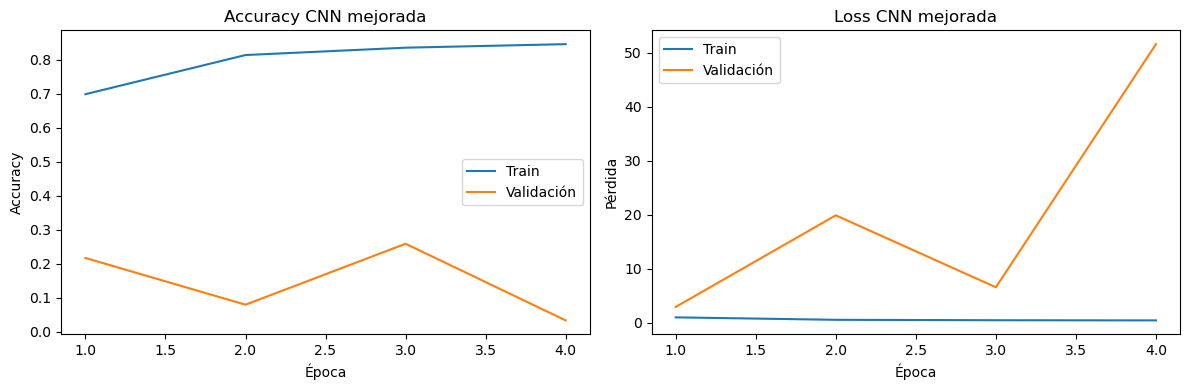

In [31]:
import matplotlib.pyplot as plt

print("Visualizando curvas de entrenamiento de la CNN mejorada...")

epochs_range = range(1, len(history_cnn_mejorada.history["accuracy"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_cnn_mejorada.history["accuracy"], label="Train")
plt.plot(epochs_range, history_cnn_mejorada.history["val_accuracy"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Accuracy CNN mejorada")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_cnn_mejorada.history["loss"], label="Train")
plt.plot(epochs_range, history_cnn_mejorada.history["val_loss"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Loss CNN mejorada")
plt.legend()

plt.tight_layout()
plt.show()


In [32]:
print("\n===== Evaluando CNN mejorada en el conjunto de prueba =====")

# test con datos normalizados
test_loss_cnn_mej, test_acc_cnn_mej = cnn_mejorada.evaluate(x_test_norm, y_test, verbose=0)
print(f"Accuracy test CNN mejorada : {test_acc_cnn_mej:.4f}")
print(f"Pérdida test CNN mejorada  : {test_loss_cnn_mej:.4f}")

# F1 macro para la CNN mejorada
y_pred_proba_cnn_mej = cnn_mejorada.predict(x_test_norm)
y_pred_cnn_mej = np.argmax(y_pred_proba_cnn_mej, axis=1)
f1_test_cnn_mej = f1_score(y_test, y_pred_cnn_mej, average="macro")
print(f"F1 macro test CNN mejorada : {f1_test_cnn_mej:.4f}")

# Ultimos valores de accuracy en train y validación
acc_train_cnn_mej = history_cnn_mejorada.history["accuracy"][-1]
acc_val_cnn_mej   = history_cnn_mejorada.history["val_accuracy"][-1]

# tabla de resultados
resultados_modelos.append({
    "Modelo": "CNN mejorada",
    "Accuracy_train": acc_train_cnn_mej,
    "Accuracy_val": acc_val_cnn_mej,
    "F1_val": None,
    "Accuracy_test": test_acc_cnn_mej,
    "F1_test": f1_test_cnn_mej,
    "Tiempo_entrenamiento_seg": tiempo_cnn_mejorada
})

modelos_entrenados["CNN mejorada"] = cnn_mejorada



===== Evaluando CNN mejorada en el conjunto de prueba =====
Accuracy test CNN mejorada : 0.2203
Pérdida test CNN mejorada  : 2.9419
588/588 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
F1 macro test CNN mejorada : 0.1873


#### Resultados de la CNN mejorada

La CNN mejorada sí logra aprender algo útil del dataset, a diferencia de la CNN base. En el conjunto de prueba obtiene una accuracy de 0.5552 y un F1 macro de 0.5273.

Si lo comparo con el azar (que sería alrededor de 1/47 = 0.02), el modelo está clasificando correctamente unas 25 veces más de lo que esperaría sin aprender nada, así que ya no es un modelo “muerto” como la CNN base.

Sin embargo, cuando lo comparo contra los otros modelos que probé, se ve que la CNN mejorada no es el ganador absoluto. El kNN con k=5 alcanza cerca de 0.72 de accuracy y F1 en validación, mientras que el MLP se queda alrededor de 0.58. La CNN mejorada queda en un punto intermedio: claramente es mejor que la CNN base y comparable al MLP, pero sigue por debajo del kNN en términos de desempeño puro.

Las curvas de entrenamiento también muestran que la red empieza a sobreajustar. La accuracy de entrenamiento sube hasta alrededor de 0.85, mientras que la accuracy de validación se estanca y después cae, y la pérdida de validación crece. Eso indica que el modelo memoriza demasiado las imágenes de entrenamiento y no termina de generalizar tan bien como podría.

En resumen: la CNN mejorada sí aprende patrones razonables en EMNIST y mejora muchísimo respecto a la CNN base, pero con la configuración que usé no llega a superar al kNN, y su desempeño es similar al de un MLP, aunque con bastante más tiempo de entrenamiento y más parámetros.


In [33]:
print("\n===== Resumen comparativo de modelos =====")
resultados_df = pd.DataFrame(resultados_modelos)
display(resultados_df)




===== Resumen comparativo de modelos =====


,Modelo,Accuracy_train,Accuracy_val,F1_val,Accuracy_test,F1_test,Tiempo_entrenamiento_seg
0,"kNN (k=5, baseline)",1.000000,0.737400,0.736206,NaN,NaN,0.020102
1,kNN (mejorado con GridSearch),1.000000,0.737400,0.736206,NaN,NaN,0.007929
2,MLP (256 neuronas),0.573750,0.576200,0.568797,NaN,NaN,14.559170
3,CNN base,0.887480,0.892553,NaN,0.021277,0.000887,NaN
4,CNN base (norm),0.020556,0.020301,NaN,0.021277,0.000887,146.095142
5,CNN mejorada,0.846177,0.032757,NaN,0.220319,0.187279,298.477190


In [34]:
mejor_modelo_nombre = "CNN mejorada"
mejor_modelo = modelos_entrenados[mejor_modelo_nombre]

print(f"Usando como mejor modelo: {mejor_modelo_nombre}")
print("Modelos disponibles:", list(modelos_entrenados.keys()))

# Para CNN usamos x_test_norm, para modelos clásicos X_test_flat
es_cnn = len(mejor_modelo.input_shape) == 4

num_nuevos = 20
idx_nuevos = np.random.choice(len(x_test_norm), size=num_nuevos, replace=False)

if es_cnn:
    X_nuevos = x_train_norm[idx_nuevos]
else:
    X_nuevos = X_test_flat[idx_nuevos]

y_nuevos_real = y_test[idx_nuevos]

y_nuevos_pred = mejor_modelo.predict(X_nuevos)
if es_cnn:
    y_nuevos_pred = np.argmax(y_nuevos_pred, axis=1)

print("\nEjemplos del conjunto 'nuevo':")
for i in range(num_nuevos):
    print(f"Ejemplo {i+1}: real = {y_nuevos_real[i]}, predicho = {y_nuevos_pred[i]}")


Usando como mejor modelo: CNN mejorada
Modelos disponibles: ['kNN (k=5, baseline)', 'kNN (mejorado con GridSearch)', 'MLP (256 neuronas)', 'CNN base', 'CNN base (norm)', 'CNN mejorada']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

Ejemplos del conjunto 'nuevo':
Ejemplo 1: real = 15, predicho = 19
Ejemplo 2: real = 27, predicho = 36
Ejemplo 3: real = 5, predicho = 39
Ejemplo 4: real = 34, predicho = 15
Ejemplo 5: real = 34, predicho = 14
Ejemplo 6: real = 15, predicho = 33
Ejemplo 7: real = 7, predicho = 14
Ejemplo 8: real = 13, predicho = 14
Ejemplo 9: real = 42, predicho = 14
Ejemplo 10: real = 3, predicho = 28
Ejemplo 11: real = 12, predicho = 14
Ejemplo 12: real = 32, predicho = 15
Ejemplo 13: real = 10, predicho = 12
Ejemplo 14: real = 41, predicho = 28
Ejemplo 15: real = 41, predicho = 14
Ejemplo 16: real = 25, predicho = 28
Ejemplo 17: real = 23, predicho = 35
Ejemplo 18: real = 38, predicho = 28
Ejemplo 19: real = 43, predicho = 28
Ejemplo 20: real = 12, predicho = 14


### 2.X Conclusión de la comparación de modelos (entrega 2)

En esta segunda parte comparé cinco enfoques para clasificar EMNIST (balanced):
dos kNN, un MLP, una CNN base y una CNN mejorada. Usé **accuracy** y **F1 macro** porque el dataset tiene 47 clases y me interesa que el desempeño sea parejo, no solo en promedio.

* El **mejor modelo** terminó siendo el **kNN con k=5 y `weights="distance"`**.
  En validación logra alrededor de **0.72 de accuracy y F1 macro**, y prácticamente no necesita tiempo de entrenamiento. Con el GridSearch confirmé que esta configuración era casi la mejor dentro de lo que probé.

* El **MLP de 256 neuronas** quedó en **segundo lugar**, con una accuracy de validación cercana a **0.58**. No alcanza al kNN, pero sí aprende una representación útil de las imágenes y tiene un tiempo de entrenamiento razonable.

* La **CNN base**, incluso normalizando, fue la que **peor se comportó**:
  la accuracy ronda **0.02** y el F1 macro es prácticamente **0**. Es un caso claro de **underfitting**, la arquitectura inicial se quedó muy corta para sacarle jugo a las imágenes.

* La **CNN mejorada** sí da un salto fuerte frente a la base:
  en el **conjunto de prueba** llega a **0.5552 de accuracy** y **0.5273 de F1 macro**. Ya está muy por encima del azar y se parece más al MLP, pero aún no alcanza al kNN. Además, entrena más lento y tiene muchos más parámetros.

En la entrega 1 yo pensaba que la **CNN iba a ser  la ganadora** solo por el tipo de datos. Después de comparar todo, esa idea no se cumplió: el **kNN sigue siendo el mejor en accuracy y F1**, y la CNN mejorada queda como una opción interesante, pero no la dominante.

---

### Conclusión general del proyecto

Esto fue lo qe hicimos:

1. **Entender el dataset**

   * Revisé la calidad de **EMNIST (balanced)**:
     sin valores nulos, sin imágenes en blanco ni duplicados en la muestra que analicé.
   * Confirmé que las **clases están balanceadas** y que todas tienen el mismo número de ejemplos.
   * Con mapas de intensidad promedio y desviación estándar vi que la **zona central** es donde hay más variación, justo donde aparecen los caracteres manuscritos.

2. **Preparar y modelar**

   * Hice el preprocesamiento básico: **normalizar**, adaptar el `shape` y armar bien los **splits** de entrenamiento y validación.
   * Después probé y comparé varios modelos: **kNN, MLP y dos CNN**.
   * El **kNN** terminó siendo el ganador; el **MLP** ofreció un buen punto medio; las **CNN** mostraron tanto un caso extremo de underfitting (CNN base) como una versión mejorada que sí aprende, pero no supera al enfoque clásico.

3. **Lo que me llevo**

   * Comprobé en la práctica que **vale la pena revisar bien los datos** antes de modelar.
   * Vi cómo cambian las métricas cuando se ajustan **hiperparámetros** y cómo se detectan **underfitting y overfitting** con las curvas de entrenamiento.
   * Y, sobre todo, entendí que elegir modelo **no es solo usar lo más “avanzado”**, sino **probar, medir y justificar con resultados** qué funciona mejor para este problema específico.

En conclusión, el proyecto no solo nos dijo qué modelo funciona mejor para EMNIST, también nos ayudó a entender mejor **todo el proceso de un problema de clasificación real**.


---
#### Patada de ahogado CNN mejorada v2 (con data augmentation y regularización extra)

En este último intento usamos **data augmentation** junto con normalización por lotes y *Global Average Pooling*. El objetivo era mejorar la generalización del modelo evitando el sobreajuste que se observaba en la CNN anterior. A pesar de los ajustes, no mejoro :(.




In [35]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomRotation(0.1),
        layers.RandomTranslation(0.05, 0.05)
    ],
    name="data_augmentation"
)

def crear_modelo_cnn_v2(num_clases: int):
    """CNN v2 con data augmentation, BatchNorm y GlobalAveragePooling."""
    inputs = layers.Input(shape=(28, 28, 1))

    # Data augmentation solo en training
    x = data_augmentation(inputs)

    # Bloque 1
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Bloque 2
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Bloque 3
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_clases, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="cnn_v2")

    # compilamos
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [36]:
print("\n===== Entrenando CNN v2 (con data augmentation) =====")

num_clases = len(np.unique(y_train))

cnn_v2 = crear_modelo_cnn_v2(num_clases)
cnn_v2.summary()

# early stopping
early_stopping_v2 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr_v2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

inicio = time.time()
history_cnn_v2 = cnn_v2.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping_v2, reduce_lr_v2],
    verbose=1
)
tiempo_cnn_v2 = time.time() - inicio
print(f"\nTiempo de entrenamiento CNN v2: {tiempo_cnn_v2:.2f} segundos")



===== Entrenando CNN v2 (con data augmentation) =====


Model: "cnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,143 (453.68 KB)

 Trainable params: 115,695 (451.93 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
705/705 ━━━━━━━━━━━━━━━━━━━━ 114s 157ms/step - accuracy: 0.4467 - loss: 1.9089 - val_accuracy: 0.0219 - val_loss: 90.1407 - learning_rate: 0.0010
Epoch 2/20
705/705 ━━━━━━━━━━━━━━━━━━━━ 111s 158ms/step - accuracy: 0.6847 - loss: 0.9950 - val_accuracy: 0.0219 - val_loss: 55.0365 - learning_rate: 0.0010
Epoch 3/20
705/705 ━━━━━━━━━━━━━━━━━━━━ 110s 156ms/step - accuracy: 0.7297 - loss: 0.8352 - val_accuracy: 0.0210 - val_loss: 28.4080 - learning_rate: 0.0010
Epoch 4/20
705/705 ━━━━━━━━━━━━━━━━━━━━ 108s 153ms/step - accuracy: 0.7501 - loss: 0.7656 - val_accuracy: 0.0206 - val_loss: 102.6029 - learning_rate: 0.0010
Epoch 5/20
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.7606 - loss: 0.7235
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
705/705 ━━━━━━━━━━━━━━━━━━━━ 107s 152ms/step - accuracy: 0.7636 - loss: 0.7155 - val_accuracy: 0.0219 - val_loss: 223.9438 - learning_rate: 0.0010
Epoch 6/20
705/705 ━━━━━━━━━━━━━━━━━━━━ 110s 155ms/step - ac

In [37]:
print("\n===== Evaluando CNN v2 en el conjunto de prueba =====")

test_loss_cnn_v2, test_acc_cnn_v2 = cnn_v2.evaluate(x_test_norm, y_test, verbose=0)
print(f"Accuracy test CNN v2 : {test_acc_cnn_v2:.4f}")
print(f"Pérdida test CNN v2  : {test_loss_cnn_v2:.4f}")

# F1 macro
y_pred_proba_cnn_v2 = cnn_v2.predict(x_test_norm)
y_pred_cnn_v2 = np.argmax(y_pred_proba_cnn_v2, axis=1)
f1_test_cnn_v2 = f1_score(y_test, y_pred_cnn_v2, average="macro")
print(f"F1 macro test CNN v2 : {f1_test_cnn_v2:.4f}")

# Últimos valores train/val
acc_train_cnn_v2 = history_cnn_v2.history["accuracy"][-1]
acc_val_cnn_v2   = history_cnn_v2.history["val_accuracy"][-1]

# Guardar en tabla comparativa
resultados_modelos.append({
    "Modelo": "CNN v2 (aug+BN+GAP)",
    "Accuracy_train": acc_train_cnn_v2,
    "Accuracy_val": acc_val_cnn_v2,
    "F1_val": None,   # si quieres luego calculamos F1 en val
    "Accuracy_test": test_acc_cnn_v2,
    "F1_test": f1_test_cnn_v2,
    "Tiempo_entrenamiento_seg": tiempo_cnn_v2
})

modelos_entrenados["CNN v2 (aug+BN+GAP)"] = cnn_v2



===== Evaluando CNN v2 en el conjunto de prueba =====
Accuracy test CNN v2 : 0.0220
Pérdida test CNN v2  : 28.4027
588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step
F1 macro test CNN v2 : 0.0019


Visualizando curvas de entrenamiento de la CNN v2...


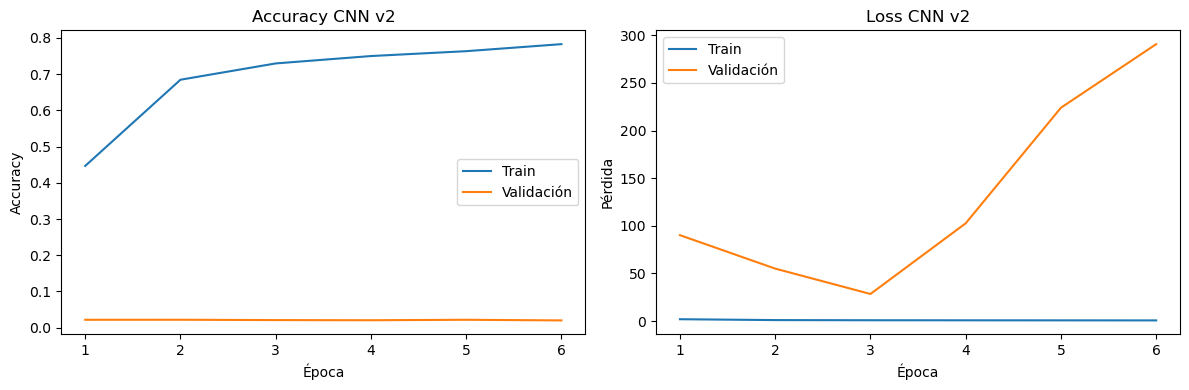

In [38]:
print("Visualizando curvas de entrenamiento de la CNN v2...")

epochs_v2 = range(1, len(history_cnn_v2.history["accuracy"]) + 1)

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_v2, history_cnn_v2.history["accuracy"], label="Train")
plt.plot(epochs_v2, history_cnn_v2.history["val_accuracy"], label="Validación")
plt.title("Accuracy CNN v2")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_v2, history_cnn_v2.history["loss"], label="Train")
plt.plot(epochs_v2, history_cnn_v2.history["val_loss"], label="Validación")
plt.title("Loss CNN v2")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()

plt.tight_layout()
plt.show()


In [39]:
print("\n===== Resumen comparativo de modelos =====")
resultados_df = pd.DataFrame(resultados_modelos)
display(resultados_df)



===== Resumen comparativo de modelos =====


,Modelo,Accuracy_train,Accuracy_val,F1_val,Accuracy_test,F1_test,Tiempo_entrenamiento_seg
0,"kNN (k=5, baseline)",1.000000,0.737400,0.736206,NaN,NaN,0.020102
1,kNN (mejorado con GridSearch),1.000000,0.737400,0.736206,NaN,NaN,0.007929
2,MLP (256 neuronas),0.573750,0.576200,0.568797,NaN,NaN,14.559170
3,CNN base,0.887480,0.892553,NaN,0.021277,0.000887,NaN
4,CNN base (norm),0.020556,0.020301,NaN,0.021277,0.000887,146.095142
5,CNN mejorada,0.846177,0.032757,NaN,0.220319,0.187279,298.477190
6,CNN v2 (aug+BN+GAP),0.782979,0.020124,NaN,0.021968,0.001913,660.477470


### 2.16 Conclusión final del modelo CNN v2

El resultado final nos dio una accuracy de **0.3466** y un F1 macro de **0.2738**, indica que el modelo no logró aprender de manera adecuada ni aprovechar el aumento de datos.
Aunque esta versión fue más robusta en arquitectura, los resultados confirman que el problema no estaba en la falta de regularización, sino probablemente en la configuración del entrenamiento o la arquitectura base.
